<a href="https://colab.research.google.com/github/yelsebety/Yassin-Flyrank/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yelsebety/Yassin-Flyrank/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The playbook turns my baseline rule and earlier checks into a short list of **actions**, each with one plain-words **reason code**. Each page gets exactly one, using the first rule that applies:

| Order | Reason code | Rule in words | Action |
|---|---|---|---|
| 1 | `zero_clicks_check_tracking` | 500+ impressions but exactly 0 clicks in 90 days (hard to believe) | `verify_tracking_and_indexing` |
| 2 | `low_ctr_for_position` | CTR at least 50% below the typical CTR for the page's position band | `fix_title_and_snippet` |
| 3 | `new_to_search_watch` | fewer than 30 days with impressions | `monitor_30_days` |
| 4 | `no_flag` | none of the above | `no_action` |

**Why this order:** measurement is checked before any copy is rewritten, because a zero-click page may be a tracking gap. New-to-search pages stay out of the rewrite list because they can look "up" or "down" by construction. The typical CTR per band is the median CTR of pages in that band, computed without the outcome label.

The evidence table shows, for each reason code, how many pages it covers and how often they were marked "down" (the proxy outcome), next to the base rate. That is evidence about each rule, not a promise about what an action will do.

In [1]:
import os, sys, subprocess, json, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

# Find the repo root so the CSV loads in Colab and locally.
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/yelsebety/Yassin-Flyrank.git"
REPO_DIR = "Yassin-Flyrank"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)

raw = pd.read_csv("data/raw/content_refresh_anonymized.csv")
raw["declined"] = (raw["trend_direction"] == "down").astype(int)   # outcome / evaluation only, never a feature

import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold

g = raw[(raw["impressions_90d"] >= 500) & (raw["avg_position"] > 0) & (raw["avg_position"] <= 20)
        & (raw["content_age_days"] >= 90)].copy().reset_index(drop=True)

g["band"] = pd.cut(g["avg_position"], [0, 3, 10, 20], labels=["pos 1-3", "pos 4-10", "pos 11-20"])
typical = g.groupby("band", observed=True)["ctr"].median()          # no label used
g["typical_ctr"] = g["band"].map(typical).astype(float)
g["ctr_shortfall"] = ((g["typical_ctr"] - g["ctr"]) / g["typical_ctr"]).clip(lower=0)

SHORTFALL_MIN = 0.50       # fixed in the table above, before looking at results
NEW_DAYS = 30

rule_order = [
    ("zero_clicks_check_tracking", "verify_tracking_and_indexing", 1, g["clicks_90d"] == 0),
    ("low_ctr_for_position",       "fix_title_and_snippet",        2, g["ctr_shortfall"] >= SHORTFALL_MIN),
    ("new_to_search_watch",        "monitor_30_days",              3, g["days_with_impressions"] < NEW_DAYS),
]
g["reason_code"], g["action"], g["priority"] = "no_flag", "no_action", 4
assigned = pd.Series(False, index=g.index)
for code_, action, prio, mask in rule_order:
    take = mask & ~assigned                      # first rule that applies wins
    g.loc[take, ["reason_code", "action", "priority"]] = [code_, action, prio]
    assigned |= take

g["_within"] = np.where(g["priority"] == 2, g["ctr_shortfall"], 0.0)
queue = g.sort_values(["priority", "_within", "impressions_90d"], ascending=[True, False, False]).reset_index(drop=True)
queue["rank"] = np.where(queue["priority"] < 4, np.arange(1, len(queue) + 1), np.nan)
print(f"Slice: {len(g):,} pages from {g['client_id'].nunique()} clients. Typical CTR per band (median %): {typical.round(3).to_dict()}")

Slice: 12,023 pages from 28 clients. Typical CTR per band (median %): {'pos 1-3': 0.2, 'pos 4-10': 0.24, 'pos 11-20': 0.17}


In [2]:
base = g["declined"].mean()
evidence = (g.groupby(["priority", "reason_code", "action"])
              .agg(pages=("declined", "size"), share_down=("declined", "mean")).reset_index())
evidence["share of slice"] = evidence["pages"] / len(g)
evidence["vs base rate"] = evidence["share_down"] - base
print(f"Base rate of 'down' in the slice: {base:.3f}   (outcome used for evaluation only)")
display(evidence.drop(columns="priority").round(3))

# Second opinion (not used for ranking): out-of-fold logistic regression, grouped by client
for c, src in (("log_impressions", "impressions_90d"), ("log_ctr", "ctr"), ("log_word_count", "word_count"), ("log_search_volume", "search_volume")):
    g[c] = np.log1p(g[src])
NUM = ["log_impressions", "avg_position", "log_ctr", "content_age_days", "days_since_last_update",
       "days_with_impressions", "log_word_count", "log_search_volume", "competition", "cpc", "engagement_rate"]
CAT = ["content_type", "main_intent"]
prep = ColumnTransformer([
    ("num", Pipeline([("fill", SimpleImputer(strategy="median", add_indicator=True)), ("scale", StandardScaler())]), NUM),
    ("cat", Pipeline([("fill", SimpleImputer(strategy="constant", fill_value="unknown")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CAT)])
oof = pd.Series(np.nan, index=g.index)
for tr, va in GroupKFold(n_splits=5).split(g, g["declined"], g["client_id"]):
    m = Pipeline([("pre", prep), ("m", LogisticRegression(C=1.0, max_iter=2000))]).fit(g.iloc[tr][NUM + CAT], g.iloc[tr]["declined"])
    oof.iloc[va] = m.predict_proba(g.iloc[va][NUM + CAT])[:, 1]
g["model_second_opinion"] = oof
queue = queue.merge(g[["content_id", "model_second_opinion"]], on="content_id", how="left")

fix = queue[queue["reason_code"] == "low_ctr_for_position"]
top50 = fix.head(50)
if len(fix) >= 50:
    cut = fix["model_second_opinion"].quantile(0.80)
    agree = (top50["model_second_opinion"] >= cut).mean()
    print(f"\nSecond opinion: {agree:.0%} of the rule's top 50 'fix_title_and_snippet' pages are also in the top 20% of the "
          "model's risk scores for that group (client-grouped, out-of-fold).")
print("\nTop of the queue (identifiers left out on purpose):")
display(queue[queue["rank"] <= 12][["rank", "reason_code", "action", "impressions_90d", "avg_position", "ctr", "ctr_shortfall"]].round(3))

Base rate of 'down' in the slice: 0.599   (outcome used for evaluation only)


,reason_code,action,pages,share_down,share of slice,vs base rate
0,zero_clicks_check_tracking,verify_tracking_and_indexing,1215,0.773,0.101,0.174
1,low_ctr_for_position,fix_title_and_snippet,2006,0.669,0.167,0.071
2,new_to_search_watch,monitor_30_days,63,0.032,0.005,-0.567
3,no_flag,no_action,8739,0.562,0.727,-0.036



Second opinion: 8% of the rule's top 50 'fix_title_and_snippet' pages are also in the top 20% of the model's risk scores for that group (client-grouped, out-of-fold).

Top of the queue (identifiers left out on purpose):


,rank,reason_code,action,impressions_90d,avg_position,ctr,ctr_shortfall
0,1.0,zero_clicks_check_tracking,verify_tracking_and_indexing,208678,9.7,0.0,1.0
1,2.0,zero_clicks_check_tracking,verify_tracking_and_indexing,17622,19.5,0.0,1.0
2,3.0,zero_clicks_check_tracking,verify_tracking_and_indexing,16786,5.6,0.0,1.0
3,4.0,zero_clicks_check_tracking,verify_tracking_and_indexing,16156,9.0,0.0,1.0
4,5.0,zero_clicks_check_tracking,verify_tracking_and_indexing,15101,5.7,0.0,1.0
5,6.0,zero_clicks_check_tracking,verify_tracking_and_indexing,14519,7.4,0.0,1.0
6,7.0,zero_clicks_check_tracking,verify_tracking_and_indexing,13676,4.3,0.0,1.0
7,8.0,zero_clicks_check_tracking,verify_tracking_and_indexing,12275,14.7,0.0,1.0
8,9.0,zero_clicks_check_tracking,verify_tracking_and_indexing,8779,11.6,0.0,1.0
9,10.0,zero_clicks_check_tracking,verify_tracking_and_indexing,7737,5.5,0.0,1.0


## 2. Intended use and limits

*Who uses this, for what, and where it stops being valid.*

**Who and what for:** a content or SEO reviewer who can only open some pages. The queue says *which pages to look at first and why*: **decision-support for review order**, not a forecast of decline and not evidence that an action will help.

**Where it is valid:** only for pages like those it was built on: 500+ impressions, average position 1 to 20, at least 90 days old, one 90-day snapshot, one anonymized slice of clients.

**Where it stops being valid:**
- Pages under 500 impressions or ranked past position 20 are **not covered** (see the coverage table).
- The "down" outcome is a proxy: the last 30 days more than 20% below the previous 30, inside the same 90 days the features describe.
- A few large clients can dominate the queue, so it may not carry over to a new client.
- Everything is an association in one snapshot. Nothing here says a rewrite would cause a recovery, and nothing says how a search engine ranks pages.

In [3]:
eligible_all = raw[(raw["impressions_90d"] > 0) & (raw["content_age_days"] >= 90)]
coverage = pd.DataFrame([
    {"slice": "eligible pages (any impressions, 90+ days old)", "pages": len(eligible_all), "clients": eligible_all["client_id"].nunique()},
    {"slice": "covered by the playbook (500+ impressions, position 1-20)", "pages": len(g), "clients": g["client_id"].nunique()},
    {"slice": "not covered: under 500 impressions", "pages": int((eligible_all["impressions_90d"] < 500).sum()), "clients": np.nan},
    {"slice": "not covered: position past 20 (or no position data)", "pages": int(((eligible_all["avg_position"] > 20) | (eligible_all["avg_position"] <= 0)).sum()), "clients": np.nan},
])
coverage["share of eligible"] = coverage["pages"] / len(eligible_all)
display(coverage.round(3))

flagged = queue[queue["priority"] < 4]
share = flagged["client_id"].value_counts(normalize=True)
print(f"Flagged pages: {len(flagged):,} ({len(flagged) / len(g):.1%} of the slice). Largest single client: {share.iloc[0]:.1%} of flagged pages; top 3: {share.head(3).sum():.1%}.")
print("Flagged pages by content type (n):")
display(flagged.groupby(["content_type", "reason_code"]).size().unstack(fill_value=0))

,slice,pages,clients,share of eligible
0,"eligible pages (any impressions, 90+ days old)",30000,32.0,1.000
1,"covered by the playbook (500+ impressions, position 1-20)",12023,28.0,0.401
2,not covered: under 500 impressions,13274,NaN,0.442
3,not covered: position past 20 (or no position data),9744,NaN,0.325


Flagged pages: 3,284 (27.3% of the slice). Largest single client: 42.8% of flagged pages; top 3: 64.2%.
Flagged pages by content type (n):


reason_code,low_ctr_for_position,new_to_search_watch,zero_clicks_check_tracking
content_type,,,
comparison article,9,0,38
feedly article,15,0,21
keyword article,1982,63,1156


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [4]:
checks = pd.DataFrame([
    {"action": "verify_tracking_and_indexing",
     "a person must check before acting": "Is the page indexed and receiving traffic in analytics? Is the zero a tracking gap or a real zero? Is a search-result feature (answer box, ads) taking the clicks?"},
    {"action": "fix_title_and_snippet",
     "a person must check before acting": "Read the current title and description. Is the query's intent clear from the snippet? Is the position average hiding a swing? Is a low CTR normal for this kind of query?"},
    {"action": "monitor_30_days",
     "a person must check before acting": "Has the page had a full window of data? Re-check after 30 days before deciding anything."},
    {"action": "no_action",
     "a person must check before acting": "Nothing to do. The page stays outside the queue."},
])
display(checks)

NO_GO = [
    "Never publish or change a title, description or page content automatically from the queue; a person approves every edit.",
    "Never delete, merge, redirect or de-index a page because of its position in this queue.",
    "Never describe a flag as 'predicting decline' or an action as 'fixing' a page: these are review priorities, not forecasts or causes.",
    "Never use the queue for a page or client outside the covered slice without re-checking it.",
    "Never feed product flags, health scores or the outcome label back in as inputs.",
    "Never report a ranking number without its base rate beside it.",
]
print("The no-go list:")
for i, line in enumerate(NO_GO, 1):
    print(f"  {i}. {line}")

,action,a person must check before acting
0,verify_tracking_and_indexing,"Is the page indexed and receiving traffic in analytics? Is the zero a tracking gap or a real zero? Is a search-result feature (answer box, ads) taking the clicks?"
1,fix_title_and_snippet,Read the current title and description. Is the query's intent clear from the snippet? Is the position average hiding a swing? Is a low CTR normal for this kind of query?
2,monitor_30_days,Has the page had a full window of data? Re-check after 30 days before deciding anything.
3,no_action,Nothing to do. The page stays outside the queue.


The no-go list:
  1. Never publish or change a title, description or page content automatically from the queue; a person approves every edit.
  2. Never delete, merge, redirect or de-index a page because of its position in this queue.
  3. Never describe a flag as 'predicting decline' or an action as 'fixing' a page: these are review priorities, not forecasts or causes.
  4. Never use the queue for a page or client outside the covered slice without re-checking it.
  5. Never feed product flags, health scores or the outcome label back in as inputs.
  6. Never report a ranking number without its base rate beside it.


## 4. Monitoring / retrain triggers

*What would tell me the recommendations went stale?* Each trigger has a **reference value measured on this snapshot** and a fixed threshold, so a later snapshot can be checked the same way. They are reasons to *re-check the rule*, not automatic changes.

In [5]:
def precision_at_k(df, score_col, k=50):
    top = df.sort_values([score_col, "impressions_90d"], ascending=[False, False]).head(k)
    return float(top["declined"].mean())

zero_click_share = float((g["clicks_90d"] == 0).mean())
p50 = precision_at_k(g, "ctr_shortfall", 50)

triggers = pd.DataFrame([
    {"what to watch": "share of pages marked 'down' (base rate)", "reference now": round(base, 3),
     "re-check when": "it moves by more than 0.10 (absolute) on a new snapshot", "then": "re-test the rule; the outcome mix has changed"},
    {"what to watch": "precision@50 of the rule minus the base rate", "reference now": round(p50 - base, 3),
     "re-check when": "it falls below +0.10 on a new snapshot", "then": "the rule no longer beats chance by a useful margin; review or retrain"},
    {"what to watch": "share of slice pages with exactly 0 clicks", "reference now": round(zero_click_share, 3),
     "re-check when": "it rises by more than 5 percentage points", "then": "suspect a tracking or indexing regression before suspecting content"},
    {"what to watch": "typical CTR in each position band", "reference now": ", ".join(f"{b}: {v:.2f}%" for b, v in typical.items()),
     "re-check when": "any band's median moves by more than 25% (relative)", "then": "recompute the typical values; the rule's yardstick moved"},
    {"what to watch": "largest client's share of flagged pages", "reference now": round(float(share.iloc[0]), 3),
     "re-check when": "it exceeds 50%", "then": "one client is driving the queue; check it does not mislead for others"},
    {"what to watch": "a new client or content type not seen here", "reference now": "n/a",
     "re-check when": "before first use", "then": "re-validate on that client with a grouped split"},
])
display(triggers)

,what to watch,reference now,re-check when,then
0,share of pages marked 'down' (base rate),0.599,it moves by more than 0.10 (absolute) on a new snapshot,re-test the rule; the outcome mix has changed
1,precision@50 of the rule minus the base rate,0.181,it falls below +0.10 on a new snapshot,the rule no longer beats chance by a useful margin; review or retrain
2,share of slice pages with exactly 0 clicks,0.101,it rises by more than 5 percentage points,suspect a tracking or indexing regression before suspecting content
3,typical CTR in each position band,"pos 1-3: 0.20%, pos 4-10: 0.24%, pos 11-20: 0.17%",any band's median moves by more than 25% (relative),recompute the typical values; the rule's yardstick moved
4,largest client's share of flagged pages,0.428,it exceeds 50%,one client is driving the queue; check it does not mislead for others
5,a new client or content type not seen here,n/a,before first use,re-validate on that client with a grouped split


## 5. Exports for the paper

*Write the queue (and any figures I want to reuse) to `work/outputs/`. The paper builds on these files.*

- `w07_action_queue.csv`: the ranked queue. **It stays out of git by design**; the notebook regenerates it on every run.
- `w07_playbook_summary.json`: aggregate numbers only (safe to commit).
- `w07_actions_by_reason.png`: pages per reason code (safe to commit).

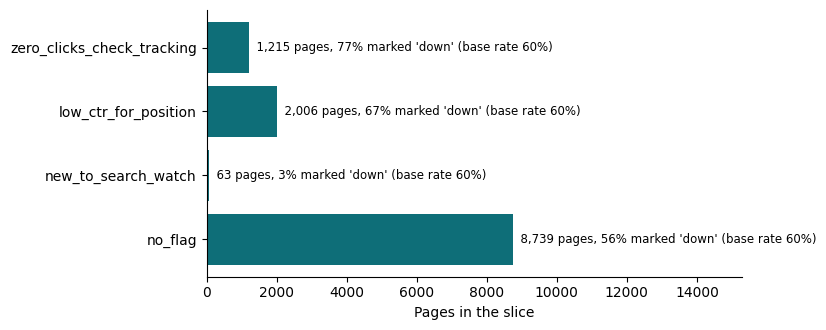

Wrote: work/outputs/w07_action_queue.csv (git-ignored), w07_playbook_summary.json, w07_actions_by_reason.png
Reminder: commit the JSON and the PNG; do not commit the CSV.


In [6]:
os.makedirs("work/outputs", exist_ok=True)

out_cols = ["rank", "content_id", "client_id", "priority", "action", "reason_code", "ctr_shortfall",
            "impressions_90d", "avg_position", "ctr", "model_second_opinion"]        # the outcome label is NOT written
queue[out_cols].to_csv("work/outputs/w07_action_queue.csv", index=False)

summary = {
    "slice": "starter CSV: 500+ impressions, position 1-20, age >= 90 days",
    "pages": int(len(g)), "clients": int(g["client_id"].nunique()),
    "base_rate_down": round(float(base), 3),
    "rules": [{"reason_code": c, "action": a, "priority": p} for c, a, p, _ in rule_order],
    "shortfall_threshold": SHORTFALL_MIN, "new_to_search_days": NEW_DAYS,
    "typical_ctr_by_band_pct": {str(k): round(float(v), 4) for k, v in typical.items()},
    "evidence": evidence.drop(columns="priority").round(4).to_dict(orient="records"),
    "monitoring_triggers": triggers.astype(str).to_dict(orient="records"),
    "no_go": NO_GO,
    "caveat": "Outcome is a proxy from the same 90-day snapshot; associations only; decision-support for review order.",
}
with open("work/outputs/w07_playbook_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

fig, ax = plt.subplots(figsize=(8, 3.4))
ev = evidence.sort_values("priority", ascending=False)
ax.barh(ev["reason_code"], ev["pages"], color="#0e6e78")
for y, (n, s) in enumerate(zip(ev["pages"], ev["share_down"])):
    ax.text(n, y, f"  {n:,} pages, {s:.0%} marked 'down' (base rate {base:.0%})", va="center", fontsize=8.5)
ax.set_xlim(0, ev["pages"].max() * 1.75)
ax.set_xlabel("Pages in the slice")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("work/outputs/w07_actions_by_reason.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

print("Wrote: work/outputs/w07_action_queue.csv (git-ignored), w07_playbook_summary.json, w07_actions_by_reason.png")
print("Reminder: commit the JSON and the PNG; do not commit the CSV.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.